<a href="https://colab.research.google.com/github/dmitryvergeles/ML_1/blob/main/machine-learning-with-tensorflow/week-01/Week1_Notebook1_Housing_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Housing Price Prediction using a Neural Network

## Objective
In this exercise, you will:
1. Create a synthetic dataset for housing prices based on a linear equation.
2. Build and train a simple neural network with one neuron to predict housing prices.

---

## Step 1: Import Libraries
Let's start by importing the necessary libraries.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


---

## Step 2: Create a Synthetic Dataset
We will create a dataset for housing prices that follows the equation

$\text{price}$ = $\text{number of bedrooms}$ $\times  x$ + $\text{base price}$


In [ ]:
# Number of samples
n_samples = 1000

# Generate random number of bedrooms between 1 and 5
bedrooms = np.random.randint(1, 6, n_samples)
print(bedrooms)

# Constants for the equation
x = 0.5  # The price added per bedroom in onehundred thousands
base_price = 1  # Base price of a house in onehundred thousands

# Generate housing prices based on the equation
prices = bedrooms * x + base_price

# Create a DataFrame
df = pd.DataFrame({'bedrooms': bedrooms, 'price': prices})

# Show the first few rows
df.head()

---

## Step 3: Visualize the Data
Plot the data to visualize the relationship between the number of bedrooms and the price.


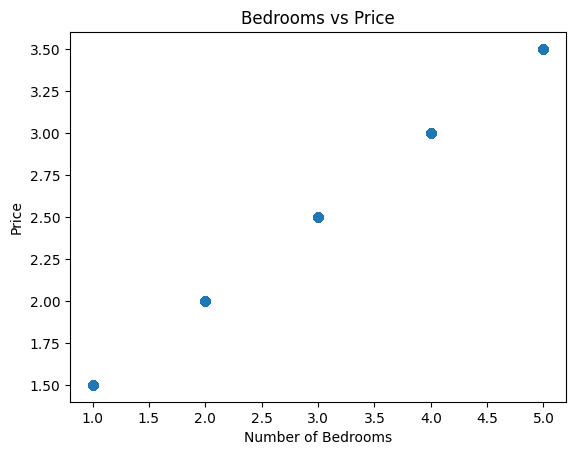

In [4]:
plt.scatter(df['bedrooms'], df['price'])
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.title('Bedrooms vs Price')
plt.show()


---

## Step 4: Preprocess the Data
Split the data into features (`X`) and labels (`y`), and then into training and testing sets.


In [ ]:
# Features and Labels
X = df[['bedrooms']]
y = df['price']

from sklearn.model_selection import train_test_split

# by splitting we should make training and testing data sets
# fatures is what we feed, Labels is what a model guesses?

# TODO Split the data
# YOUR CODE HERE

x_train, x_test, y_train, y_test = train_test_split(X,y)

print(y_train)
print(y_test)


---

## Step 5: Build a Neural Network
Build a simple neural network with one neuron to predict the house prices.
Pick a loss function that suits this problem.


In [22]:
# TODO Create the model
from tensorflow import keras
from keras import layers

# TODO Compile the model
model = keras.Sequential()
model.add(layers.Input(shape=[1]))
model.add(layers.Dense(units=1))


# TODO print a Summary of the model
model.summary()
# Hint: for the parameters to show, you need to define an Input layer; alternatively, you can inspect the summary after fitting the model


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

---

## Step 6: Train the Model
Train the model using the training data.


In [28]:
# TODO Train the model

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=10)


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: 2.5296
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0000e+00 - loss: 2.2224
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 1.9436
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 1.6933
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 1.4695  
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 1.2707 
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 1.0937 
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.9379 
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.8022 
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.6836 


---

## Step 7: Evaluate the Model
Evaluate the model using the test data and plot its prediction.


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.6267 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
     bedrooms  predicted_price
0           3         1.708461
1           3         1.708461
2           1         0.706970
3           3         1.708461
4           1         0.706970
..        ...              ...
995         3         1.708461
996         4         2.209206
997         3         1.708461
998         3         1.708461
999         5         2.709952

[1000 rows x 2 columns]


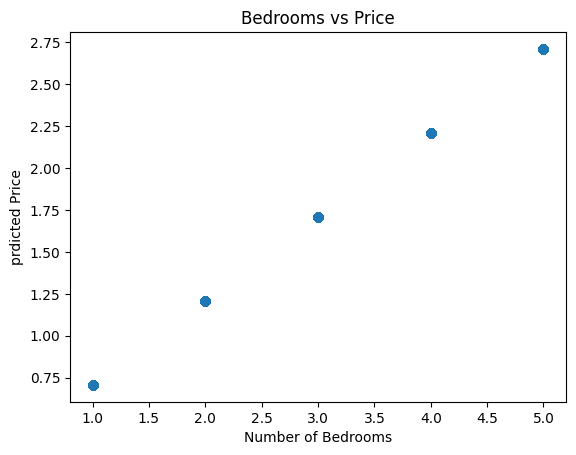

In [36]:
# TODO Evaluate the model using the model.evaluate() function

model.evaluate(x_test,y_test)

# TODO Make predictions

predictions = model.predict(X) #df['bedrooms']

df_new = pd.DataFrame({'bedrooms': df['bedrooms'], 'predicted_price': predictions.flatten()})

print(df_new )



# TODO Plot real vs predicted prices (hint: you can use the plotting code from above as a start)

plt.scatter(df_new['bedrooms'], df_new['predicted_price'])
plt.xlabel('Number of Bedrooms')
plt.ylabel('prdicted Price')
plt.title('Bedrooms vs Price')
plt.show()

# Step 8: Optional
Go back to the start and experiment what happens if instead of representing a price of a house costing onehundred thousand by a 1 we use the raw number 100,000 instead.

Try to explain what happened and why.